In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# Customer Intelligence System using Classification, Ensemble Learning and Clustering

## Business Objective

HELP International wants to identify countries that require humanitarian aid the most. Using socio-economic and health indicators, we will segment countries and build predictive models to support data-driven decision making.

### Techniques Used
- K-Means Clustering
- DBSCAN Clustering
- Logistic Regression
- Random Forest
- XGBoost
- Feature Importance Analysis

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [23]:
df = pd.read_csv(
    '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv'
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Objective**

Load the Country Development dataset into a Pandas DataFrame and inspect its structure.

# Dataset Overview

**Objective**

Perform an initial inspection of the dataset.

In [24]:
print("Data Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

df.info()

Data Types


country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


Missing Values


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Duplicate Records
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# Statistical Summary

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


**Analysis**

Observe:


1. Countries with extremely high GDP
2. High inflation countries
3. Low life expectancy countries


These characteristics help segmentation.

# Univariate EDA

**Objective**

Study the distribution of each feature individually.

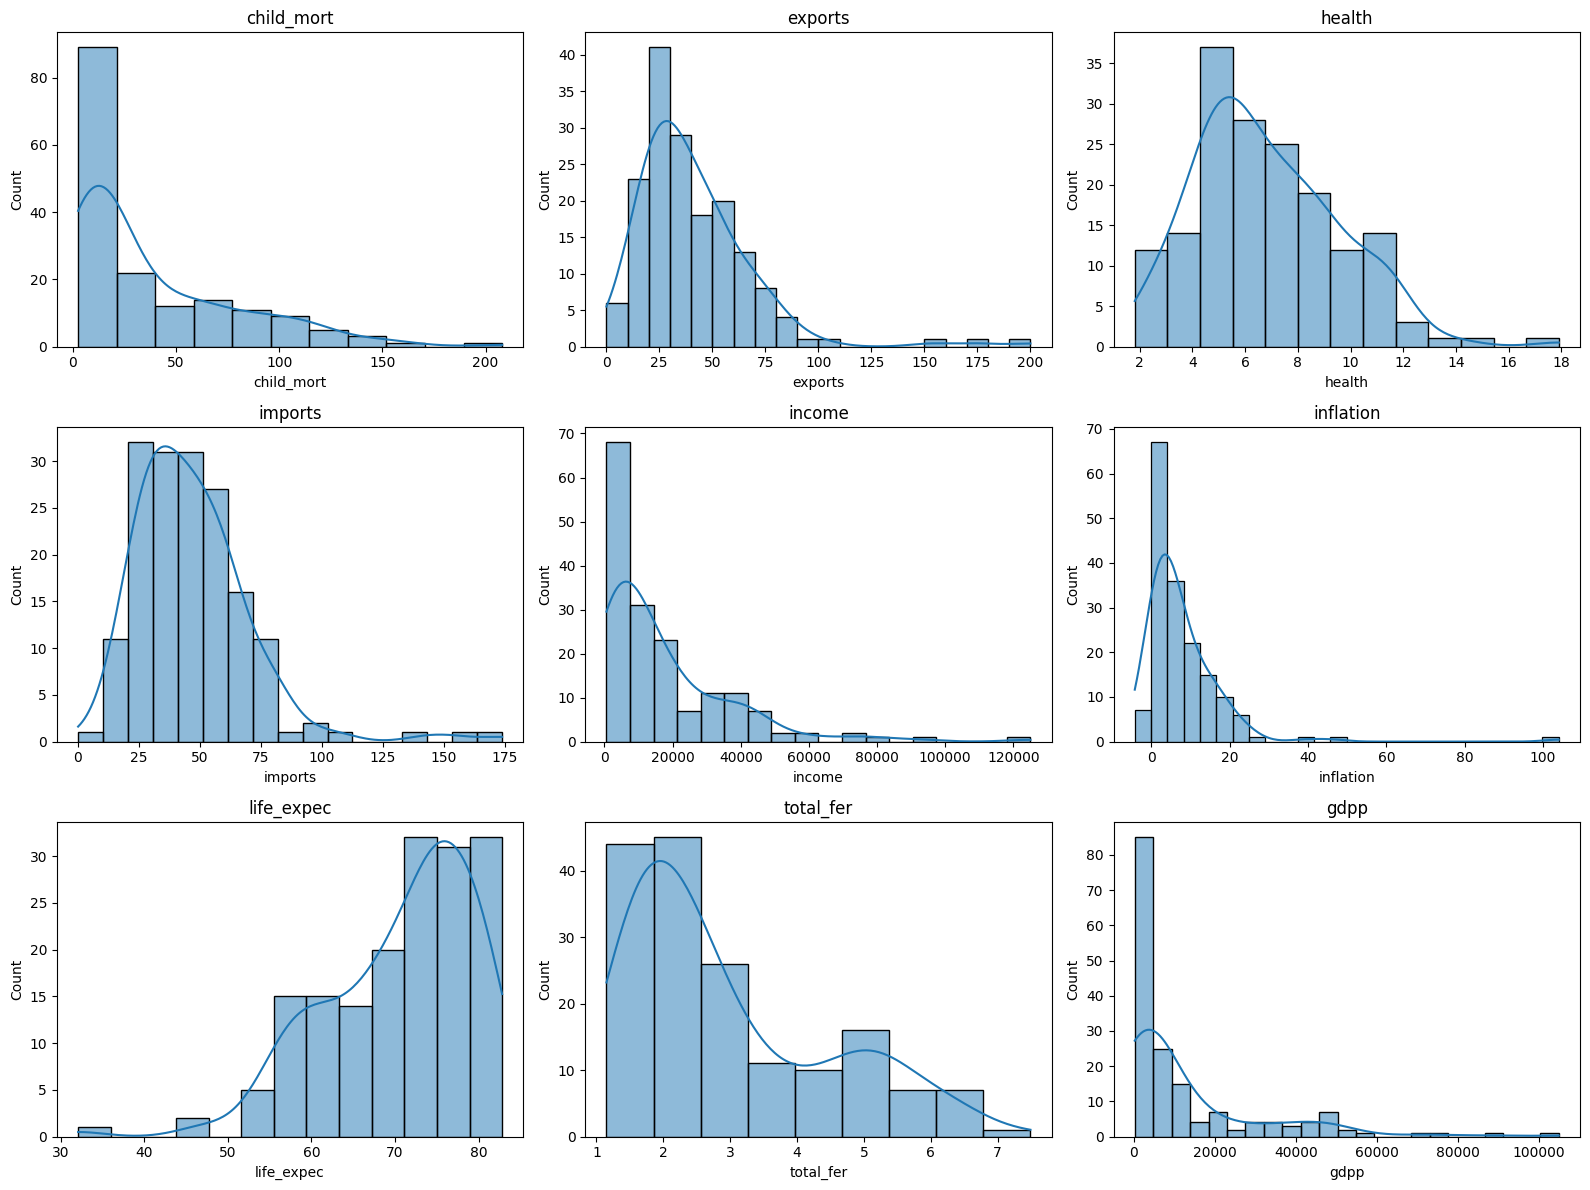

In [26]:
numerical_cols = df.drop('country', axis=1).columns

plt.figure(figsize=(16,12))

for i,col in enumerate(numerical_cols):
    
    plt.subplot(3,3,i+1)
    
    sns.histplot(
        df[col],
        kde=True
    )
    
    plt.title(col)

plt.tight_layout()
plt.show()

# Correlation Analysis

**Objective**

Analyze relationships between variables.

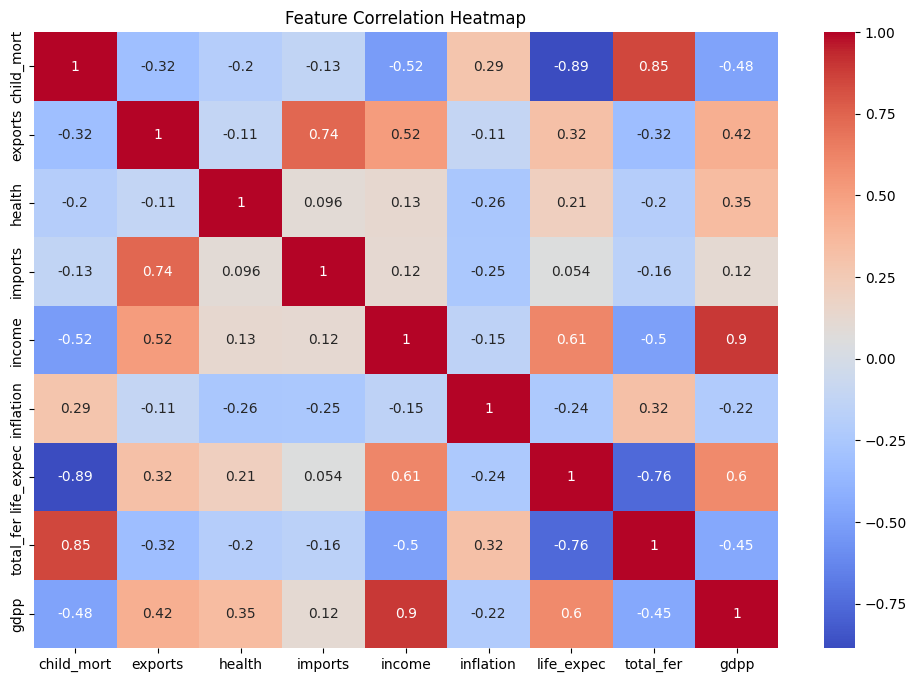

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop('country',axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

**Insights**

Look for:


1. income ↔ gdpp
2. child_mort↔ total_fer
3. life_expec ↔ child_mort


# Outlier Analysis

**Objective**

Identify extreme observations using boxplots.

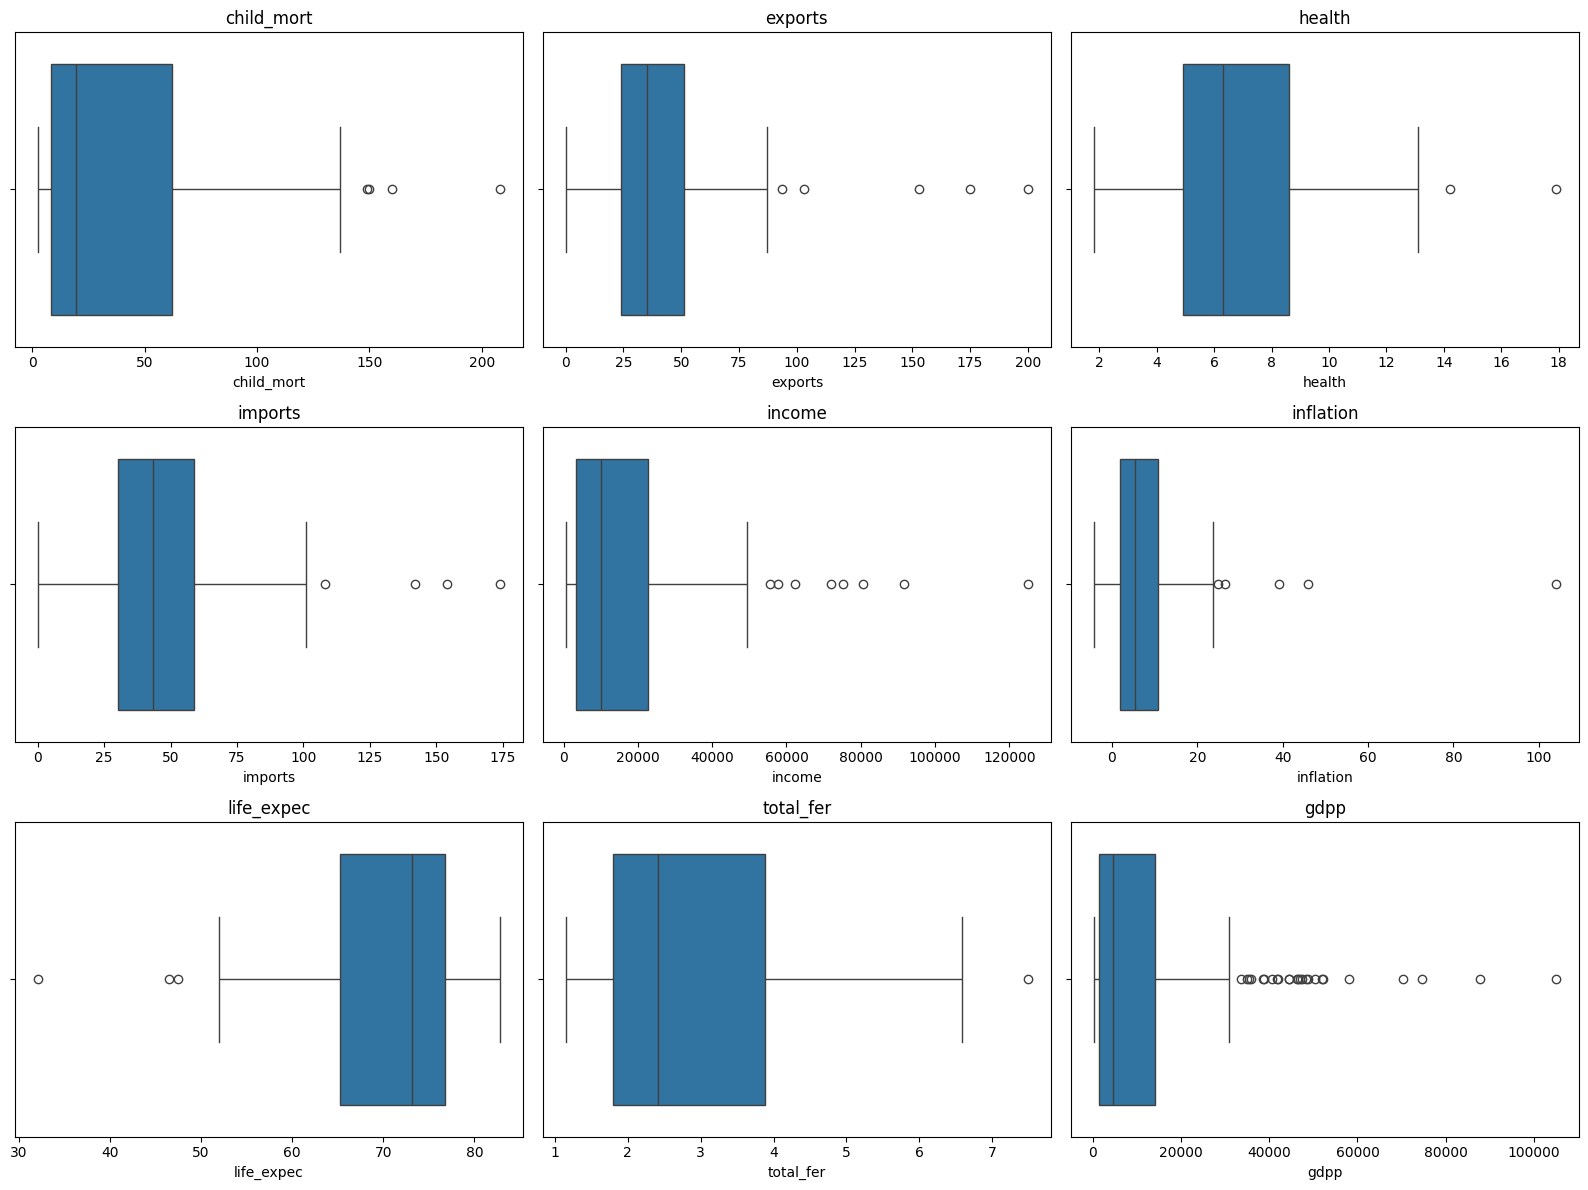

In [28]:
plt.figure(figsize=(16,12))

for i,col in enumerate(numerical_cols):
    
    plt.subplot(3,3,i+1)
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(col)

plt.tight_layout()
plt.show()

# Data Preparation & Scaling

**Objective**

Prepare data for clustering.

In [29]:
countries = df['country']

X = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


# PCA Visualization

**Expected Insight**

Countries with similar socioeconomic profiles should appear closer together in PCA space.

Explained Variance: [0.4595174  0.17181626]


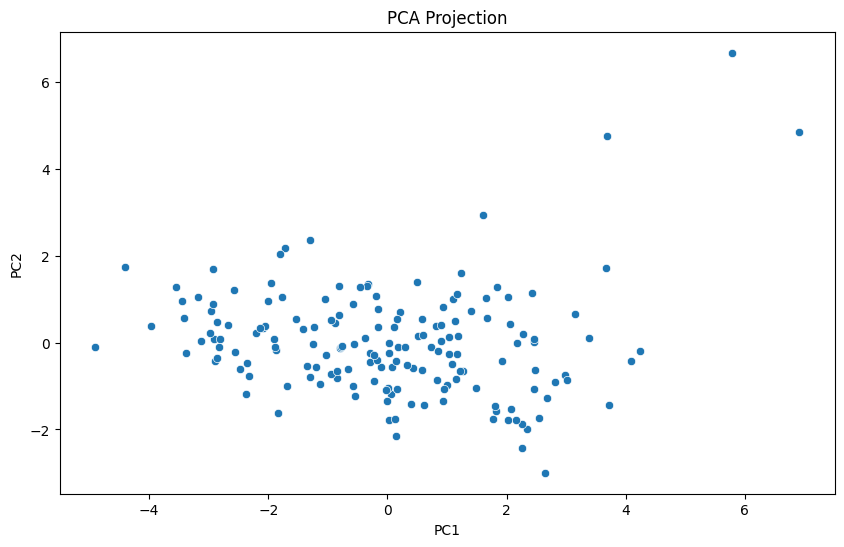

In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df
)

plt.title("PCA Projection")

plt.show()

# Elbow Method

K-Means requires the number of clusters (K) as input.

The Elbow Method helps determine an appropriate value.

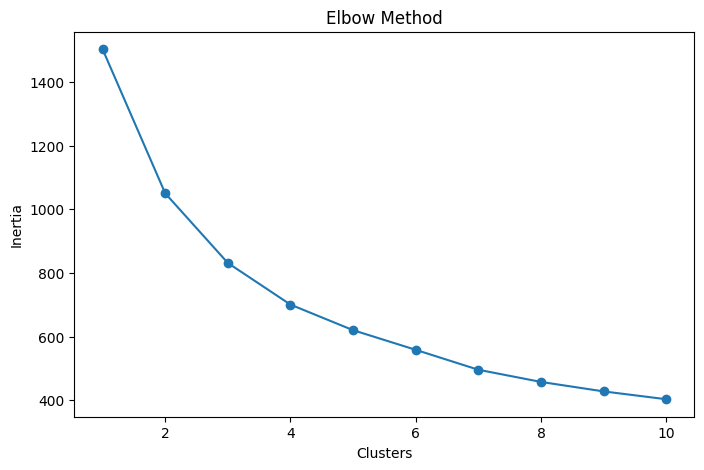

In [31]:
inertia = []

for k in range(1,11):
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

# K-Means Clustering

K-Means identifies groups based on feature similarity.

Countries within the same cluster should have similar:

Income
GDP
Health indicators
Life expectancy

In [32]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

df['Cluster'] = kmeans_labels

score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "Silhouette Score:",
    round(score,3)
)

df['Cluster'].value_counts()

Silhouette Score: 0.283


Cluster
2    84
1    47
0    36
Name: count, dtype: int64

# Cluster Visualization & Profiling

**Objective**

Interpret the meaning of each cluster.

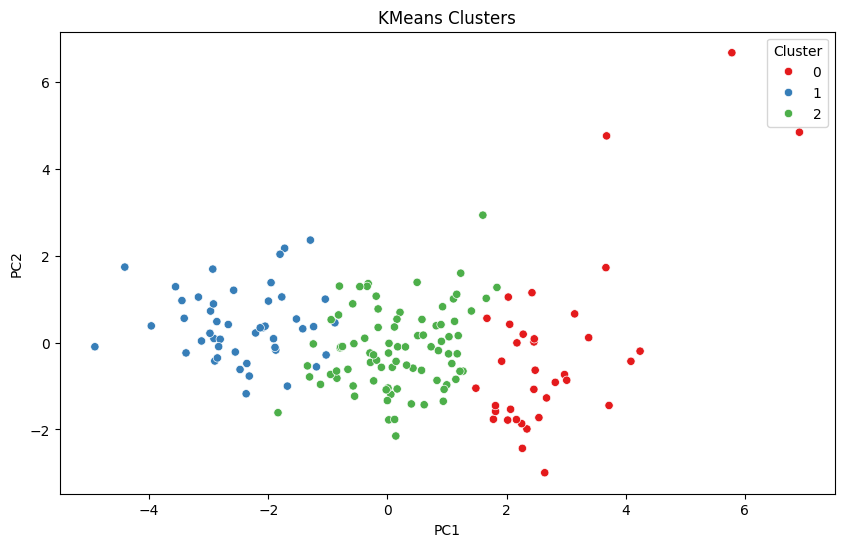

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [33]:
pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df
)

plt.title("KMeans Clusters")

plt.show()

cluster_profile = df.groupby(
    'Cluster'
).mean(numeric_only=True)

display(cluster_profile)

**Interpretation**

Identify:


1. Developed countries
2. Developing countries
3. Underdeveloped countries


based on GDP, income, life expectancy, etc.

# DBSCAN Clustering

Unlike K-Means:

DBSCAN does not require specifying K.
DBSCAN can identify noise and outliers.

In [34]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

db_labels = dbscan.fit_predict(
    X_scaled
)

df['DBSCAN_Cluster'] = db_labels

print(
    "DBSCAN Clusters:",
    np.unique(db_labels)
)

print(
    "Number of Clusters:",
    len(set(db_labels))
)

DBSCAN Clusters: [-1  0  1  2]
Number of Clusters: 4


# Random Forest, XGBoost & Conclusion

Random Forest Accuracy: 1.0
XGBoost Accuracy: 0.9705882352941176


,Feature,Importance
0,child_mort,0.251179
8,gdpp,0.199593
7,total_fer,0.174030
6,life_expec,0.161208
4,income,0.144110
2,health,0.031770
5,inflation,0.016104
3,imports,0.011648
1,exports,0.010357


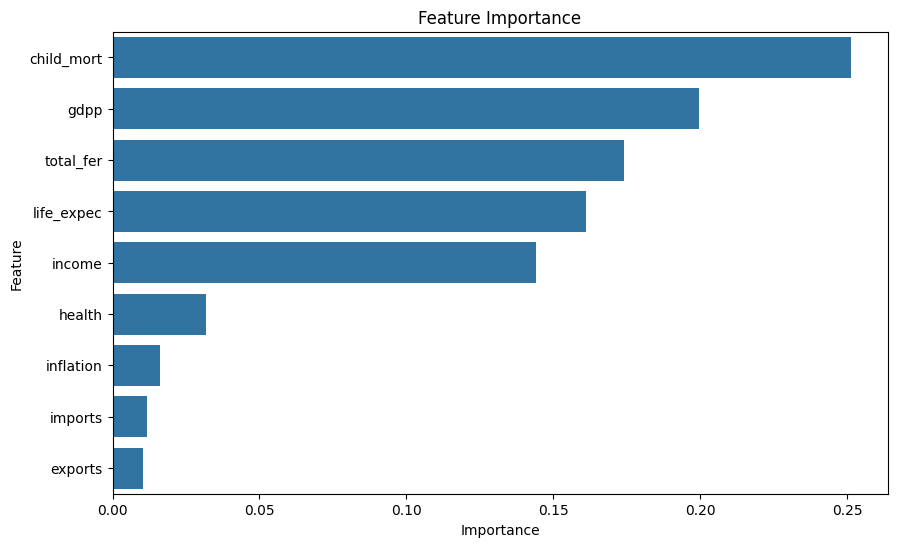


CONCLUSION
- KMeans successfully segmented countries into meaningful groups.
- Silhouette Score was used to evaluate cluster quality.
- DBSCAN identified density-based patterns and noise.
- Random Forest and XGBoost accurately predicted cluster membership.
- Income, GDP per capita and child mortality were among the most influential features.


In [35]:
y = kmeans_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

# XGBoost

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

print("\nCONCLUSION")
print("- KMeans successfully segmented countries into meaningful groups.")
print("- Silhouette Score was used to evaluate cluster quality.")
print("- DBSCAN identified density-based patterns and noise.")
print("- Random Forest and XGBoost accurately predicted cluster membership.")
print("- Income, GDP per capita and child mortality were among the most influential features.")

## Conclusion

This  developed a Country Intelligence System using unsupervised and supervised machine learning techniques.

Exploratory Data Analysis revealed strong relationships among socioeconomic indicators, particularly between income, GDP per capita, life expectancy, and child mortality. Feature scaling was applied to ensure fair contribution of all variables during clustering.

K-Means clustering successfully segmented countries into meaningful groups representing different levels of economic and social development. Cluster quality was evaluated using the Silhouette Score, indicating effective separation among clusters. DBSCAN was additionally applied to identify density-based structures and potential outlier countries.

To validate the usefulness of the generated segments, Random Forest and XGBoost classifiers were trained using cluster labels as targets. Both models achieved strong predictive performance, demonstrating that the clusters captured meaningful patterns within the data.

Feature importance analysis showed that income, GDP per capita, child mortality, and life expectancy were among the most influential factors driving segmentation.

Overall, the project successfully combined exploratory data analysis, clustering, dimensionality reduction, ensemble learning, and model evaluation to generate actionable insights from socioeconomic data.


### Final insights-Cluster Observations

1. **Cluster with High Child Mortality**

   * The cluster with the highest average child mortality rate also shows lower life expectancy, lower income levels, and higher fertility rates.
   * This cluster represents the most economically challenged and underdeveloped countries.

2. **Cluster with High Income and GDP per Capita**

   * The cluster with the highest average income and GDP per capita consists of economically developed nations.
   * These countries generally have better healthcare systems, lower child mortality rates, and higher life expectancy.

3. **Underdeveloped Cluster**

   * The underdeveloped cluster is characterized by low income, low GDP per capita, high child mortality, and relatively poor health indicators.
   * Countries in this cluster face significant socioeconomic challenges and require developmental support.

4. **Countries that Should be Prioritized for Aid**

   * Countries belonging to the underdeveloped cluster should be prioritized for international aid and development programs.
   * Priority should be given to nations with extremely high child mortality, low life expectancy, and low GDP per capita, as these indicators reflect urgent developmental needs.

5. **Overall Segmentation Insight**

   * The clustering process successfully separated countries into distinct groups representing developed, developing, and underdeveloped economies.
   * Income, GDP per capita, life expectancy, and child mortality emerged as the most important factors influencing country segmentation.
